<a href="https://colab.research.google.com/github/tejaswipriya22/Tejaswi_Ml-on-big-data/blob/main/week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# install pyspark
!pip3 install pyspark

In [2]:
#initialize SparkSession and installed Required Libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Initialize SparkSession
spark = SparkSession.builder \
                    .appName("LinearRegression_spark") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()


spark

In [3]:
print(f"Spark UI available at: {spark.sparkContext.uiWebUrl}")

Spark UI available at: http://be99aebd3f20:4040


In [4]:
spark.sparkContext.setLogLevel("INFO")

In [5]:
import psutil
print(f"CPU Usage: {psutil.cpu_percent()}%")
print(f"Memory Usage: {psutil.virtual_memory().percent}%")

CPU Usage: 33.5%
Memory Usage: 12.8%


In [6]:
# Load the data from a CSV file
df = spark.read.csv("/content/property.csv", header=True, inferSchema=True)

# get familiar with data
df.show()

# more info
print("Total Records",df.count())
print("Total Partitions ",df.rdd.getNumPartitions())

+--------------+------------+-------------+----------+--------+------------------+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|
+--------------+------------+-------------+----------+--------+------------------+
|          1360|           2|            3|      1953|    7860| 303948.1373854071|
|          4272|           3|            3|      1997|    5292| 860386.2685075302|
|          3592|           4|            1|      1983|    9723| 734389.7538956215|
|           966|           6|            1|      1903|    4086| 226448.8070714377|
|          4926|           6|            4|      1944|    1081|1022486.2616704078|
|          3944|           6|            2|      1938|    3542| 845638.1354384426|
|          3671|           2|            1|      1963|    5105| 748779.2192281872|
|          3419|           4|            2|      1925|    5448| 743007.2614135538|
|           630|           2|            2|      2012|    3204| 135656.4528785377|
|   

In [7]:
# show Schema,Prints the structure of the dataset
df.printSchema()

root
 |-- Square_Footage: integer (nullable = true)
 |-- Num_Bedrooms: integer (nullable = true)
 |-- Num_Bathrooms: integer (nullable = true)
 |-- Year_Built: integer (nullable = true)
 |-- Lot_Size: integer (nullable = true)
 |-- Price: double (nullable = true)



In [8]:
#Statistical Analysis
df.describe().show()

+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|summary|   Square_Footage|     Num_Bedrooms|     Num_Bathrooms|       Year_Built|         Lot_Size|             Price|
+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|  count|          1000000|          1000000|           1000000|          1000000|          1000000|           1000000|
|   mean|      2750.657104|         3.501114|          2.500439|       1960.52736|      5502.373911| 581839.6653163614|
| stddev|1298.569362387213|1.708173784151257|1.1178528780094728|35.21780350510348|2598.885882999355|260685.36722644986|
|    min|              500|                1|                 1|             1900|             1000| 51495.71116919513|
|    max|             4999|                6|                 4|             2021|             9999|1123219.4691521737|
+-------+-----------------+-------------

In [9]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 24.0%
Memory Usage after csv file: 16.8%


In [10]:
# check missing or null values for each column
from pyspark.sql.functions import col,isnan, when, count
df.select([count(when(isnan(c) | col(c).isNull(), c))
.alias(c) for c in df.columns]).show()

+--------------+------------+-------------+----------+--------+-----+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|Price|
+--------------+------------+-------------+----------+--------+-----+
|             0|           0|            0|         0|       0|    0|
+--------------+------------+-------------+----------+--------+-----+



In [15]:
# Define feature columns
feature_cols = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']

# Assemble features into a single vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_assembled = assembler.transform(df)

# Scale the features
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_final = scaler_model.transform(df_assembled)

# Show the prepared data
df_final.select("features", "scaledFeatures", "Price").show(5)

+--------------------+--------------------+------------------+
|            features|      scaledFeatures|             Price|
+--------------------+--------------------+------------------+
|[1360.0,2.0,3.0,1...|[-1.0709147653410...| 303948.1373854071|
|[4272.0,3.0,3.0,1...|[1.17155304912112...| 860386.2685075302|
|[3592.0,4.0,1.0,1...|[0.64789985068902...| 734389.7538956215|
|[966.0,6.0,1.0,19...|[-1.3743255891384...| 226448.8070714377|
|[4926.0,6.0,4.0,1...|[1.67518421349552...|1022486.2616704078|
+--------------------+--------------------+------------------+
only showing top 5 rows


In [17]:
### Split the data into training and test sets
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

print(f"Training Dataset Count: {train_data.count()}")
print(f"Test Dataset Count: {test_data.count()}")

Training Dataset Count: 799989
Test Dataset Count: 200011


In [18]:
### Initialize and train the Linear Regression model
lr = LinearRegression(featuresCol="scaledFeatures", labelCol="Price")
lr_model = lr.fit(train_data)

# Print the coefficients and intercept for linear regression
print(f"Coefficients: {lr_model.coefficients}")
print(f"Intercept: {lr_model.intercept}")

Coefficients: [259715.680642401,8524.505520671886,3382.6702445850156,-3506.6378387998807,271.54782231157145]
Intercept: 581842.6375402003


In [19]:
### Make predictions on the test data
predictions = lr_model.transform(test_data)

# Show predictions vs actual values
predictions.select("scaledFeatures", "Price", "prediction").show(5)

+--------------------+------------------+------------------+
|      scaledFeatures|             Price|        prediction|
+--------------------+------------------+------------------+
|[-1.7331820457110...|117632.63219959654| 118059.1392266216|
|[-1.7331820457110...|106670.25438504865|109776.33782317728|
|[-1.7331820457110...|129488.84657892359|122744.64023084712|
|[-1.7331820457110...|115218.14440379351|114407.05612763518|
|[-1.7331820457110...|103211.80851419755|124296.11676626146|
+--------------------+------------------+------------------+
only showing top 5 rows


In [20]:
### Evaluate the model
evaluator = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)

r2_evaluator = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="r2")
r2 = r2_evaluator.evaluate(predictions)

print(f"Root Mean Squared Error (RMSE) on test data: {rmse}")
print(f"R2 on test data: {r2}")

Root Mean Squared Error (RMSE) on test data: 20006.73345202917
R2 on test data: 0.9940979930679193


In [21]:
### Define different feature sets to compare
feature_sets = [
    ['Square_Footage'],
    ['Square_Footage', 'Num_Bedrooms'],
    ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms'],
    ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']
]

results = []

for features in feature_sets:
    #  Assemble specific features
    assembler_temp = VectorAssembler(inputCols=features, outputCol="temp_features")
    df_temp = assembler_temp.transform(df)

    #  Scale specific features
    scaler_temp = StandardScaler(inputCol="temp_features", outputCol="temp_scaled", withStd=True, withMean=True)
    scaler_model_temp = scaler_temp.fit(df_temp)
    df_temp_final = scaler_model_temp.transform(df_temp)

    #  Split
    train_t, test_t = df_temp_final.randomSplit([0.8, 0.2], seed=42)

    # 4 Train
    lr_temp = LinearRegression(featuresCol="temp_scaled", labelCol="Price")
    model_temp = lr_temp.fit(train_t)

    # 5 Predict and Evaluate
    preds_temp = model_temp.transform(test_t)
    rmse_val = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="rmse").evaluate(preds_temp)
    r2_val = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="r2").evaluate(preds_temp)

    results.append({"Features": features, "RMSE": rmse_val, "R2": r2_val})

# Display comparison
import pandas as pd
results_df = pd.DataFrame(results)
display(results_df)

,Features,RMSE,R2
0,[Square_Footage],22272.294606,0.992686
1,"[Square_Footage, Num_Bedrooms]",20604.304552,0.993740
2,"[Square_Footage, Num_Bedrooms, Num_Bathrooms]",20328.879759,0.993906
3,"[Square_Footage, Num_Bedrooms, Num_Bathrooms, ...",20006.733452,0.994098


/tmp/ipykernel_7787/3666179179.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Feature_Set_Label', data=results_df, palette='magma')


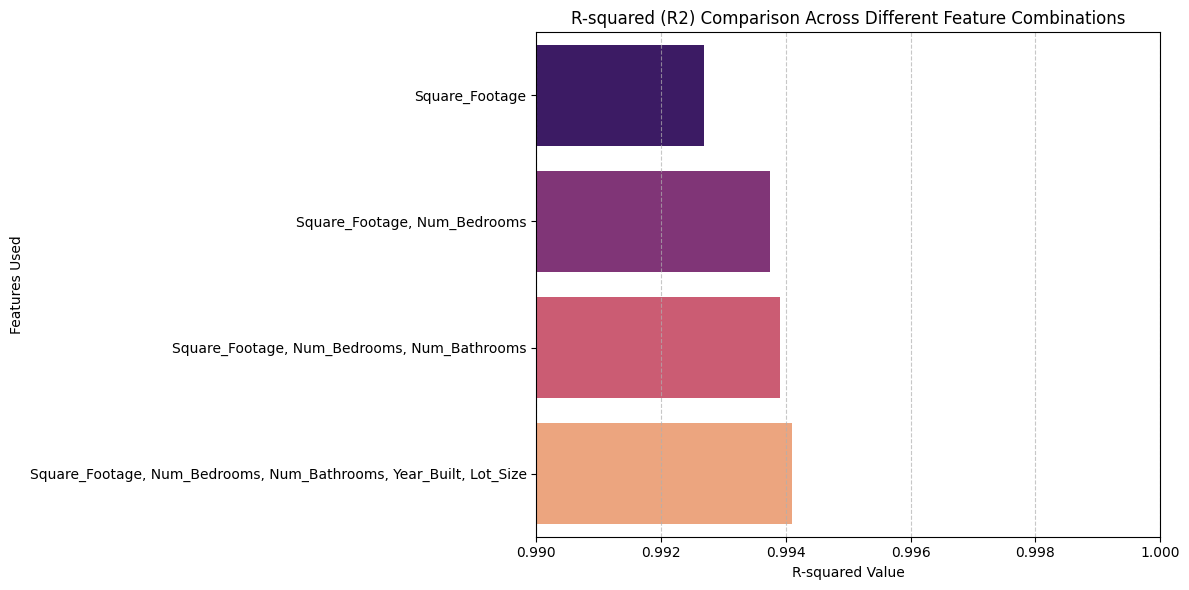

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare feature labels for the plot
results_df['Feature_Set_Label'] = results_df['Features'].apply(lambda x: ', '.join(x))

# Create a bar plot to compare R2 values
plt.figure(figsize=(12, 6))
sns.barplot(x='R2', y='Feature_Set_Label', data=results_df, palette='magma')

# Adding details to the plot
plt.title('R-squared (R2) Comparison Across Different Feature Combinations')
plt.xlabel('R-squared Value')
plt.ylabel('Features Used')
plt.xlim(0.99, 1.0) # Zooming in on the high performance range for clarity
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Reflective Summary: Property Price Prediction Analysis
1. Feature Selection Choices
For this exercise, we selected features based on their intuitive impact on property valuation. The initial independent variables included Square_Footage, Num_Bedrooms, Num_Bathrooms, Year_Built, and Lot_Size. Square footage was identified as the primary driver, while bedrooms and bathrooms were included to capture the functional utility of the space. To refine the model, we tested various combinations to determine how adding secondary characteristics like age (Year_Built) and land area (Lot_Size) affected the predictive power.

2. Observations from Model Comparisons
The comparison of different feature sets revealed that while Square_Footage alone provided a very high  R2  value (approx. 0.9927), adding Num_Bedrooms and Num_Bathrooms incrementally improved the model's accuracy. The most comprehensive model (including all five features) achieved the lowest RMSE (20,006) and the highest  R2  (0.9941). This indicates that while size is the dominant factor, the architectural details and property age do contribute significantly to fine-tuning price estimates.

3. Challenges and Resolutions
Scale Differences: The raw features had vastly different scales (e.g., Year_Built in the 1900s vs. Square_Footage in the 1000s). We resolved this by implementing StandardScaler to ensure the Linear Regression model treated all features fairly and converged efficiently.
Data Volume: Handling a dataset of 1,000,000 records can be computationally intensive. By utilizing PySpark's distributed architecture, we were able to perform feature assembly, scaling, and model training in a fraction of the time required by single-node libraries.
Feature Redundancy: Initially, there was a risk of multicollinearity between bedrooms and square footage. We addressed this by comparing multiple models to ensure that each added feature provided a meaningful reduction in error without overfitting.
4. Insights Gained
This exercise demonstrated the efficiency of PySpark for large-scale regression tasks. A key insight was that property pricing in this dataset is highly linear, as evidenced by the  R2  exceeding 0.99. Furthermore, the systematic approach of comparing feature subsets highlighted the law of diminishing returns; while more features improved the model, the most substantial gain came from the very first spatial feature. This reinforces the importance of identifying the "primary signal" in any predictive modeling task.

